In [3]:
import pandas as pd

file_name = "/content/fund_overlap_dataset.csv"
df = pd.read_csv(file_name)

print(df.shape)
df.head()

(100000, 9)


,date,fund_name,amc,category,isin,company,sector,pct_nav,market_value
0,2023-01-31,Aravali ELSS Fund,Aravali,ELSS,INE002A01018,Reliance Industries Ltd,Energy,9.2745,1765.59
1,2023-01-31,Aravali ELSS Fund,Aravali,ELSS,INE009A01021,Infosys Ltd,IT,8.5060,1619.29
2,2023-01-31,Aravali ELSS Fund,Aravali,ELSS,INE238A01034,Axis Bank Ltd,Financials,5.8695,1117.38
3,2023-01-31,Aravali ELSS Fund,Aravali,ELSS,INE467B01029,Tata Consultancy Services Ltd,IT,5.3939,1026.84
4,2023-01-31,Aravali ELSS Fund,Aravali,ELSS,INE397D01024,Bharti Airtel Ltd,Telecom,5.1738,984.94


In [4]:
#total Rows#
len(df)

100000

In [5]:
#Number of funds#
df["fund_name"].nunique()

50

In [6]:
#Number of month-end dates#
df["date"] = pd.to_datetime(df["date"])

print("Funds:", df["fund_name"].nunique())
print("Dates:", df["date"].nunique())
print("First date:", df["date"].min().date())
print("Last date:", df["date"].max().date())

Funds: 50
Dates: 36
First date: 2023-01-31
Last date: 2025-12-31


In [7]:
#Remove Cash before counting equity ISINs#
equity = df[df["isin"] != "CASH_EQV"].copy()

print("Different equity ISINs:", equity["isin"].nunique())

Different equity ISINs: 350


In [9]:
#Count Cash rows#
cash_rows = (df["isin"] == "CASH_EQV").sum()
print("Cash rows:", cash_rows)
df.groupby(["fund_name", "date"]).size().shape

Cash rows: 1800


(1800,)

In [12]:
#Check whether pct_nav adds to 100#
fund_month_totals = (
    df.groupby(["fund_name", "date"])["pct_nav"]
      .sum()
      .reset_index(name="pct_nav_total")
)

print("Number of fund-month combinations:",
      len(fund_month_totals))

print("Smallest total:",
      fund_month_totals["pct_nav_total"].min())

print("Largest total:",
      fund_month_totals["pct_nav_total"].max())
check = (fund_month_totals["pct_nav_total"] - 100).abs() < 0.0001

print("All totals equal 100:", check.all())

Number of fund-month combinations: 1800
Smallest total: 100.0
Largest total: 100.0
All totals equal 100: True


In [13]:
#ISIN versus company name#
print("Different ISINs:", df["isin"].nunique())
print("Different company names:", df["company"].nunique())

Different ISINs: 351
Different company names: 355


In [14]:
#one ISIN appears with more than one company spelling:#
isin_company = (
    equity.groupby("isin")["company"]
    .nunique()
)

affected_isins = isin_company[isin_company > 1]

print(affected_isins)

isin
INE002A01018    2
INE009A01021    2
INE040A01034    2
INE467B01029    2
Name: company, dtype: int64


In [20]:
#display the actual spellings:#
affected = (
    equity[equity["isin"].isin(affected_isins.index)]
    .groupby("isin")["company"]
    .unique()
)

for isin, companies in affected.items():
    print(isin, "->", list(companies))

INE002A01018 -> ['Reliance Industries Ltd', 'Reliance Inds Ltd']
INE009A01021 -> ['Infosys Ltd', 'Infosys Limited']
INE040A01034 -> ['HDFC Bank Ltd', 'HDFC Bank Limited']
INE467B01029 -> ['Tata Consultancy Services Ltd', 'Tata Consultancy Services Limited']


Grouping by company name could split the same security into separate holdings, causing the merged portfolio and overlap calculations to understate the true common exposure.

In [27]:
#First remove cash#
equity = df[df["isin"] != "CASH_EQV"].copy()
#Filter the date#
dec25 = equity[equity["date"] == "2025-12-31"].copy()
#Then create a function for pairwise overlap#
def calculate_overlap(data, fund1, fund2):
    f1 = data[data["fund_name"] == fund1][["isin", "pct_nav"]].rename(
        columns={"pct_nav": "weight1"}
    )

    f2 = data[data["fund_name"] == fund2][["isin", "pct_nav"]].rename(
        columns={"pct_nav": "weight2"}
    )

    merged = pd.merge(f1, f2, on="isin", how="inner")

    merged["minimum_weight"] = merged[["weight1", "weight2"]].min(axis=1)

    overlap = merged["minimum_weight"].sum()

    common_stocks = len(merged)

    return overlap, common_stocks, merged

In [28]:
result1 = calculate_overlap(
    dec25,
    "Aravali Large Cap Fund",
    "Nilgiri Large Cap Fund"
)

result2 = calculate_overlap(
    dec25,
    "Chenab Small Cap Fund",
    "Chenab Index Fund"
)

print("Aravali vs Nilgiri")
print("Overlap:", round(result1[0], 2))
print("Common stocks:", result1[1])

print("\nChenab Small Cap vs Chenab Index")
print("Overlap:", round(result2[0], 2))
print("Common stocks:", result2[1])

Aravali vs Nilgiri
Overlap: 56.59
Common stocks: 40

Chenab Small Cap vs Chenab Index
Overlap: 0.5
Common stocks: 2


In [30]:
#Merged portfolio#
investments = {
    "Aravali Large Cap Fund": 400000,
    "Nilgiri Large Cap Fund": 300000,
    "Brindavan Flexi Cap Fund": 200000,
    "Satpura ELSS Fund": 100000
}

portfolio = equity[
    (equity["date"] == "2025-12-31") &
    (equity["fund_name"].isin(investments.keys()))
].copy()

portfolio["invested_amount"] = portfolio.apply(
    lambda row: investments[row["fund_name"]] * row["pct_nav"] / 100,
    axis=1
)

merged_portfolio = (
    portfolio.groupby(["isin", "company"], as_index=False)["invested_amount"]
    .sum()
)

In [31]:
#Number of different stocks#
different_stocks = merged_portfolio["isin"].nunique()

print("Different stocks:", different_stocks)

Different stocks: 118


In [32]:
#Top five stock exposures#
merged_portfolio["corpus_pct"] = (
    merged_portfolio["invested_amount"] / 1000000 * 100
)

top5 = merged_portfolio.sort_values(
    "invested_amount", ascending=False
).head(5)

print(top5[["isin", "company", "invested_amount", "corpus_pct"]])

            isin                        company  invested_amount  corpus_pct
11  INE040A01034                  HDFC Bank Ltd          58431.5     5.84315
73  INE467B01029  Tata Consultancy Services Ltd          56987.2     5.69872
9   INE030A01027         Hindustan Unilever Ltd          44215.6     4.42156
48  INE238A01034                  Axis Bank Ltd          41809.0     4.18090
41  INE192A01025     Tata Consumer Products Ltd          34758.5     3.47585


In [33]:
top5["amount_rupees"] = top5["invested_amount"].round(2)
top5["share_of_corpus_pct"] = top5["corpus_pct"].round(2)

print(
    top5[
        ["isin", "company",
         "amount_rupees",
         "share_of_corpus_pct"]
    ]
)

            isin                        company  amount_rupees  \
11  INE040A01034                  HDFC Bank Ltd        58431.5   
73  INE467B01029  Tata Consultancy Services Ltd        56987.2   
9   INE030A01027         Hindustan Unilever Ltd        44215.6   
48  INE238A01034                  Axis Bank Ltd        41809.0   
41  INE192A01025     Tata Consumer Products Ltd        34758.5   

    share_of_corpus_pct  
11                 5.84  
73                 5.70  
9                  4.42  
48                 4.18  
41                 3.48  


In [34]:
#Stocks above 5% of the total corpus#
above_5 = merged_portfolio[
    merged_portfolio["corpus_pct"] > 5
].copy()

print(
    above_5[
        ["isin", "company",
         "invested_amount",
         "corpus_pct"]
    ]
)

            isin                        company  invested_amount  corpus_pct
11  INE040A01034                  HDFC Bank Ltd          58431.5     5.84315
73  INE467B01029  Tata Consultancy Services Ltd          56987.2     5.69872


In [35]:
#Now calculate how many of the four funds hold each stock#
fund_count = (
    portfolio.groupby("isin")["fund_name"]
    .nunique()
    .reset_index(name="funds_holding")
)

above_5 = above_5.merge(fund_count, on="isin")

print(
    above_5[
        ["isin", "company",
         "invested_amount",
         "corpus_pct",
         "funds_holding"]
    ]
)

           isin                        company  invested_amount  corpus_pct  \
0  INE040A01034                  HDFC Bank Ltd          58431.5     5.84315   
1  INE467B01029  Tata Consultancy Services Ltd          56987.2     5.69872   

   funds_holding  
0              2  
1              4  


In [36]:
#36-month overlap#
fund1 = "Aravali Large Cap Fund"
fund2 = "Brindavan Flexi Cap Fund"

dates = sorted(equity["date"].unique())

monthly_results = []

for date in dates:
    month_data = equity[equity["date"] == date]

    overlap, common_stocks, _ = calculate_overlap(
        month_data,
        fund1,
        fund2
    )

    monthly_results.append({
        "date": date,
        "overlap": overlap,
        "common_stocks": common_stocks
    })

monthly_overlap = pd.DataFrame(monthly_results)

print(monthly_overlap)

         date  overlap  common_stocks
0  2023-01-31  42.2920             25
1  2023-02-28  42.1392             23
2  2023-03-31  41.9744             23
3  2023-04-30  41.6328             25
4  2023-05-31  41.9160             24
5  2023-06-30  41.2908             24
6  2023-07-31  40.8646             23
7  2023-08-31  41.6723             24
8  2023-09-30  40.7771             24
9  2023-10-31  39.1259             24
10 2023-11-30  37.9301             24
11 2023-12-31  38.2155             25
12 2024-01-31  38.1600             23
13 2024-02-29  39.5971             24
14 2024-03-31  37.4312             24
15 2024-04-30  36.5275             24
16 2024-05-31  35.5528             25
17 2024-06-30  36.6215             26
18 2024-07-31  34.6184             24
19 2024-08-31  36.2553             23
20 2024-09-30  33.8940             22
21 2024-10-31  36.7605             25
22 2024-11-30  36.9526             25
23 2024-12-31  33.9501             25
24 2025-01-31  33.2958             23
25 2025-02-2

In [37]:
#First month#
print(monthly_overlap.iloc[0])

date             2023-01-31 00:00:00
overlap                       42.292
common_stocks                     25
Name: 0, dtype: object


In [38]:
#Last month#
print(monthly_overlap.iloc[-1])

date             2025-12-31 00:00:00
overlap                       27.087
common_stocks                     26
Name: 35, dtype: object


In [39]:
#Change#
change = (
    monthly_overlap.iloc[-1]["overlap"]
    - monthly_overlap.iloc[0]["overlap"]
)

print("Change:", change)

Change: -15.205000000000002


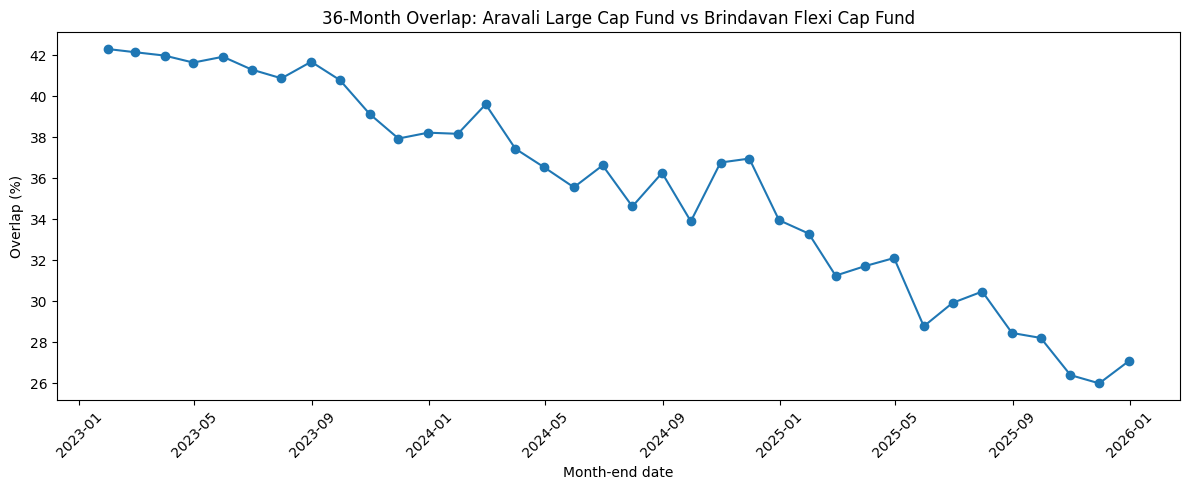

In [40]:
#Create the 36-month chart#
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_overlap["date"],
    monthly_overlap["overlap"],
    marker="o"
)

plt.xlabel("Month-end date")
plt.ylabel("Overlap (%)")
plt.title(
    "36-Month Overlap: Aravali Large Cap Fund vs Brindavan Flexi Cap Fund"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()